[22:52:13] [INFO] ============================================================
[22:52:13] [INFO]   PHASE 1 — DETERMINISTIC INGESTION & PREPROCESSING
[22:52:13] [INFO] ============================================================
[22:52:13] [INFO]   Input  : utensils.mp4
[22:52:13] [INFO]   Output : /content/local_output
[22:52:13] [INFO] [1.1 CFR] Source 30.00 fps → Target 30 fps  |  Step: every 1 src frames  |  ~898 output frames
[22:52:13] [INFO] [1.2 CLAHE] GPU mode (CuPy+cucim)  clip=2.0  grid=(8, 8)
[22:52:13] [INFO] [1.3 Spatial] Resolution: 448x448  |  Stabilise: False
[22:52:13] [INFO] [1.4 Buffer] Sliding window init — size=16  (≈533 ms @ 30 fps)
[22:52:13] [INFO] [Demo] Writer opened → /content/local_output/side_by_side.mp4
[22:52:13] [INFO] [Main Loop] Processing frames …
[22:52:13] [INFO] [GPU] CuPy not available — using CPU resize
[22:52:32] [INFO]   … 100 frames  (5.5 fps)  buffers=85
[22:52:51] [INFO]   … 200 frames  (5.4 fps)  buffers=185
[22:53:08] [INFO]   … 300 frames

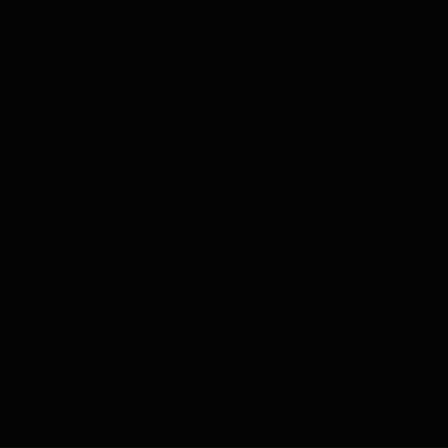



zip error: Interrupted (aborting)
cp: cannot create regular file '/content/drive/MyDrive/phase1_results.zip': No such file or directory


In [ ]:
# 0. Install GPU libraries (cupy-cuda12x matches Colab T4's CUDA 12)
!pip install opencv-python-headless numpy -q
!pip install cupy-cuda12x cucim-cu12 -q

!mkdir -p /content/local_output

# Run — T4 will now handle resize + CLAHE
!python phase1_pipeline.py \
    --input utensils.mp4 \
    --output /content/local_output \
    --width 448 --height 448 \
    --no-stabilise

import glob, json, os
from IPython.display import Image, display

meta_path = '/content/local_output/phase1_meta.json'
if os.path.exists(meta_path):
    meta = json.load(open(meta_path))
    print("\n── Phase 1 Metrics ──")
    for k, v in meta.items():
        print(f"  {k:<35} {v}")
    frames = sorted(glob.glob('/content/local_output/processed_frames/*.jpg'))
    if frames:
        display(Image(frames[0], width=700))
else:
    print("❌ Script did not complete — check error above")

!zip -q -r phase1_results.zip /content/local_output
!cp phase1_results.zip /content/drive/MyDrive/phase1_results.zip

In [ ]:
import os

# Create the target directory if it doesn't exist
output_dir = 'phase1_output'
os.makedirs(output_dir, exist_ok=True)

# Unzip the results into the new directory
!unzip -q /content/phase1_results.zip -d {output_dir}

✅ Frames found: 898
[23:08:20] [INFO] ============================================================
[23:08:20] [INFO]   PHASE 2 — Zero-Shot Feature Extraction
[23:08:20] [INFO] ============================================================
[23:08:20] [INFO] [Meta] Loaded Phase 1 metadata: fps=30  δt=0.0333s
[23:08:20] [INFO] [Source] Phase 1 frames: 898 images
[23:08:20] [INFO] [Init] Initialising pipeline components …
2026-04-18 23:08:22.400283: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 23:08:22.848761: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-18 23:08:23.127264: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776553703.472569   29420 cuda_dnn.cc:8579] Unable to register

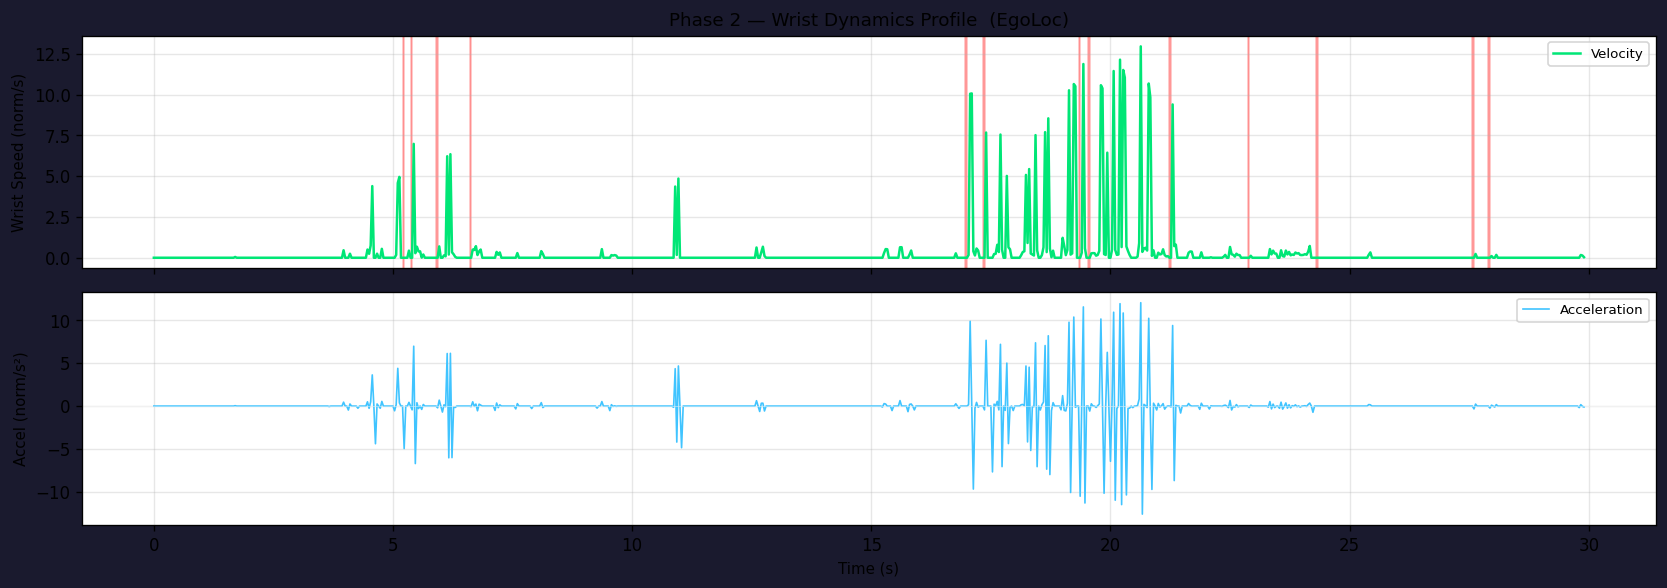

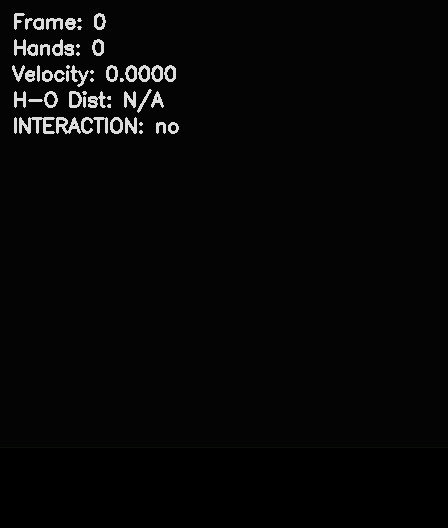

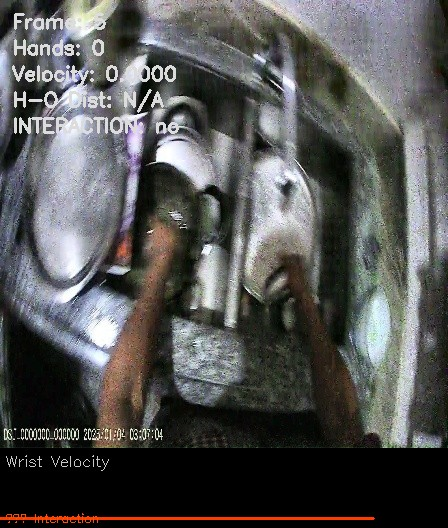

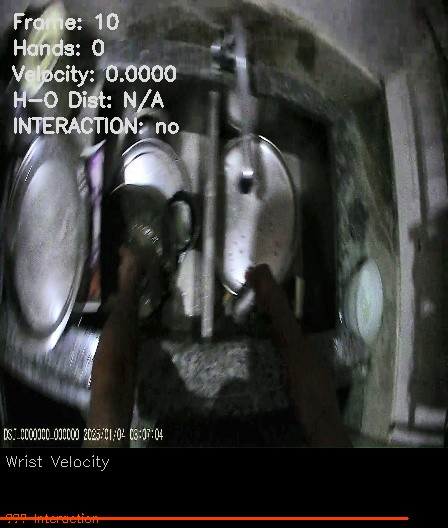

In [ ]:
# ── 1. Unzip Phase 1 results to the exact folder Phase 2 expects ──
!unzip -q /content/phase1_results.zip -d /content/
# This puts frames at /content/local_output/processed_frames/
# Now symlink so Phase 2 finds them at the hardcoded 'phase1_output' path
!rm -rf /content/phase1_output
!ln -s /content/local_output /content/phase1_output

# ── 2. Verify frames are visible before running Phase 2 ──
import glob
frames = glob.glob('/content/phase1_output/processed_frames/*.jpg')
print(f"✅ Frames found: {len(frames)}")
if not frames:
    print("❌ Still empty — check the zip contents below:")
    !unzip -l /content/phase1_results.zip | head -20

# ── 3. Install deps ──
!pip install mediapipe==0.10.14 opencv-python-headless matplotlib tqdm -q

# ── 4. Clean old broken output and run Phase 2 ──
!rm -rf /content/phase2_output
!python phase2_extraction.py --data-dir /content/phase1_output --output /content/phase2_output

# ── 5. Show results ──
import json, os
from IPython.display import Image, display

meta_path = '/content/phase2_output/phase2_meta.json'
if os.path.exists(meta_path):
    print("\n── Phase 2 Metrics ──")
    meta = json.load(open(meta_path))
    for k, v in meta.items():
        print(f"  {k:<35} {v}")
else:
    print("❌ Phase 2 did not complete — check error above")

if os.path.exists('/content/phase2_output/velocity_plot.png'):
    display(Image('/content/phase2_output/velocity_plot.png', width=900))

for fp in sorted(glob.glob('/content/phase2_output/visualisations/*.jpg'))[:3]:
    display(Image(fp, width=700))

[23:39:14] [INFO] ============================================================
[23:39:14] [INFO]   PHASE 3 — EgoLoc Temporal Interaction Localisation
[23:39:14] [INFO] ============================================================
[23:39:14] [INFO] [Meta] Phase 2 meta loaded — fps=30
[23:39:14] [INFO] [Source] Loading Phase 2 velocity profile: phase2_output/velocity_profiles/velocity_profile.npy
[23:39:14] [INFO] [Source] Extracting distances from phase2_features.jsonl …
[23:39:14] [INFO] [Source] Total frames to process: 898
[23:39:14] [INFO] [Init] Initialising Phase 3 components …
[23:39:14] [INFO] [Init] Using Distance-Dominant Hysteresis Engine (continuous manipulation mode)
[23:39:15] [DEBUG] [Hysteresis] CONTACT locked @ 508
[23:39:15] [DEBUG] [Hysteresis] SEPARATION @ 641 (133 frames)
[23:39:15] [DEBUG] [Hysteresis] CONTACT locked @ 702
[23:39:15] [DEBUG] [Hysteresis] SEPARATION @ 726 (24 frames)
[23:39:15] [INFO] [Hysteresis] 2 episodes detected (thr=0.550, trigger=15f, release=

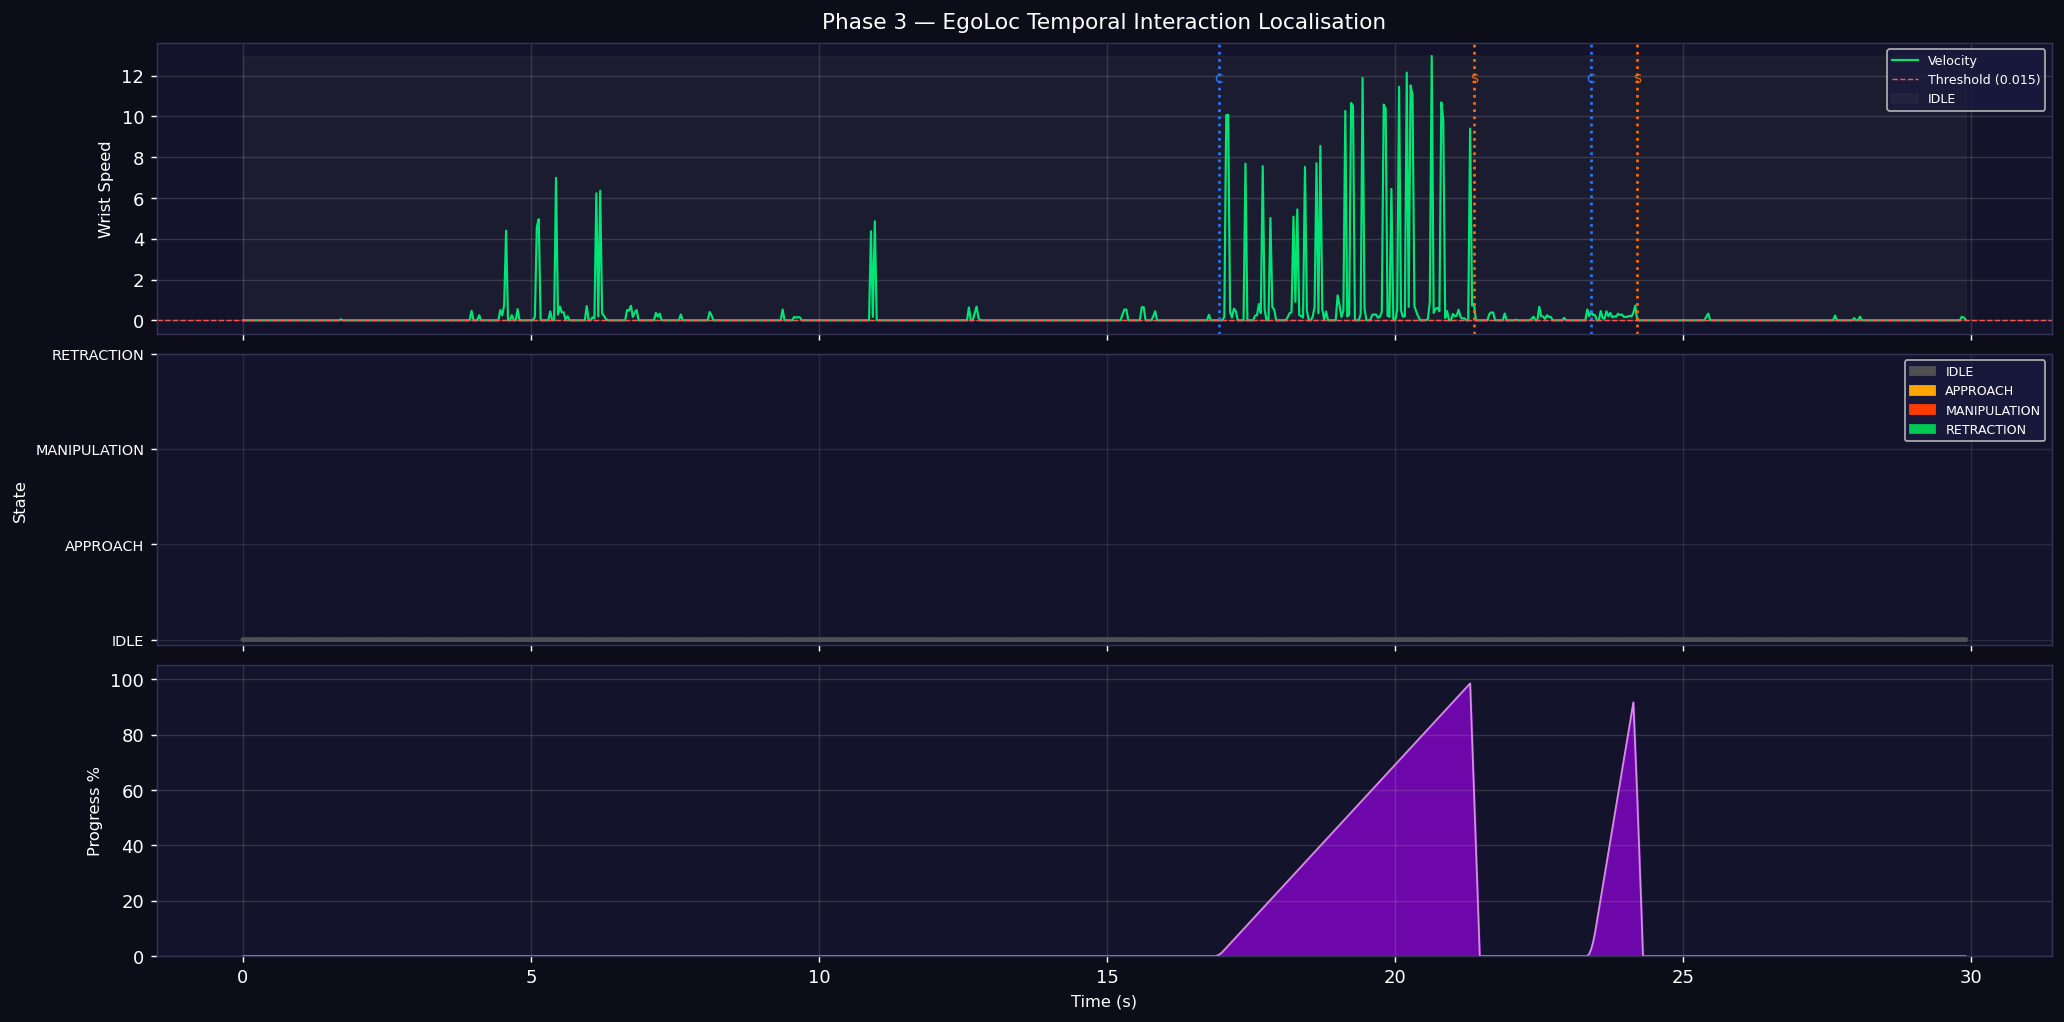

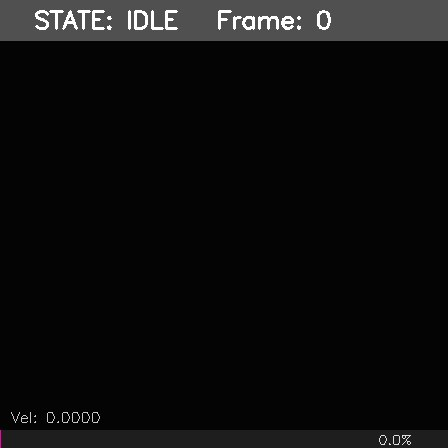

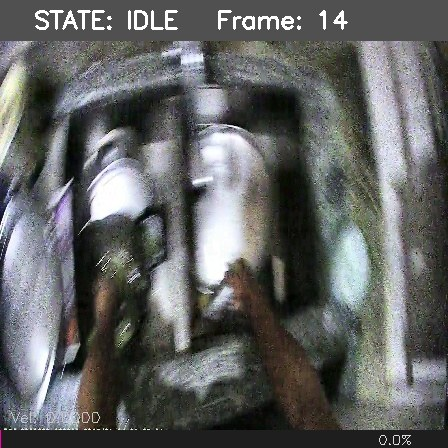

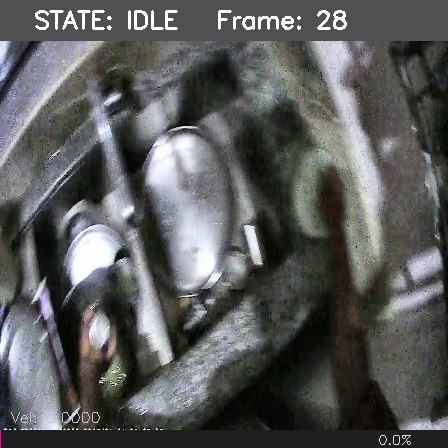

In [ ]:
!pip install opencv-python-headless numpy matplotlib tqdm scipy -q
!rm -rf phase3_output
!python phase3_egoloc_til.py --data-dir phase2_output

import glob, json
from IPython.display import Image, display
print("\n── Phase 3 Metrics ──")
meta = json.load(open('phase3_output/phase3_meta.json'))
for k, v in meta.items():
    print(f"  {k:<38} {v}")
display(Image('phase3_output/phase3_timeline_plot.png', width=900))
for fp in sorted(glob.glob('phase3_output/visualisations/*.jpg'))[:3]:
    display(Image(fp, width=700))

[23:42:13] [INFO] ============================================================
[23:42:13] [INFO]   PHASE 4+5  —  ProTAS + VLA Alignment
[23:42:13] [INFO] ============================================================
[23:42:13] [INFO] [Data] Loading Phase 3 from: phase3_output
[23:42:13] [INFO] [Data] Frames=898, FPS=30, Events=2, Segments=1
[23:42:13] [INFO] [4.1] Temporal aggregation done — 898 frames, buffer=16
[23:42:13] [INFO] [4.2] Progress prediction done — max=0.000, episodes detected.
[23:42:13] [INFO] [4.3] Task-graph audit: 1 clean, 0 flagged
[23:42:13] [INFO] [4.4] Action primitive cutting: 1 clips from 2 cut points
[23:42:13] [INFO] [4] Phase 4 done — 1 action primitive clips
Phase 5: VLA enrichment: 100%|███████████████████| 1/1 [00:00<00:00, 689.85it/s]
[23:42:13] [INFO] [5] Phase 5 enrichment done — 1 clips annotated
[23:42:13] [INFO] [5.4] Exported 1 VLA records → phase45_output/phase45_vla.jsonl
[23:42:13] [INFO] [5.4] Pretty JSON → phase45_output/vla_ready_dataset.json

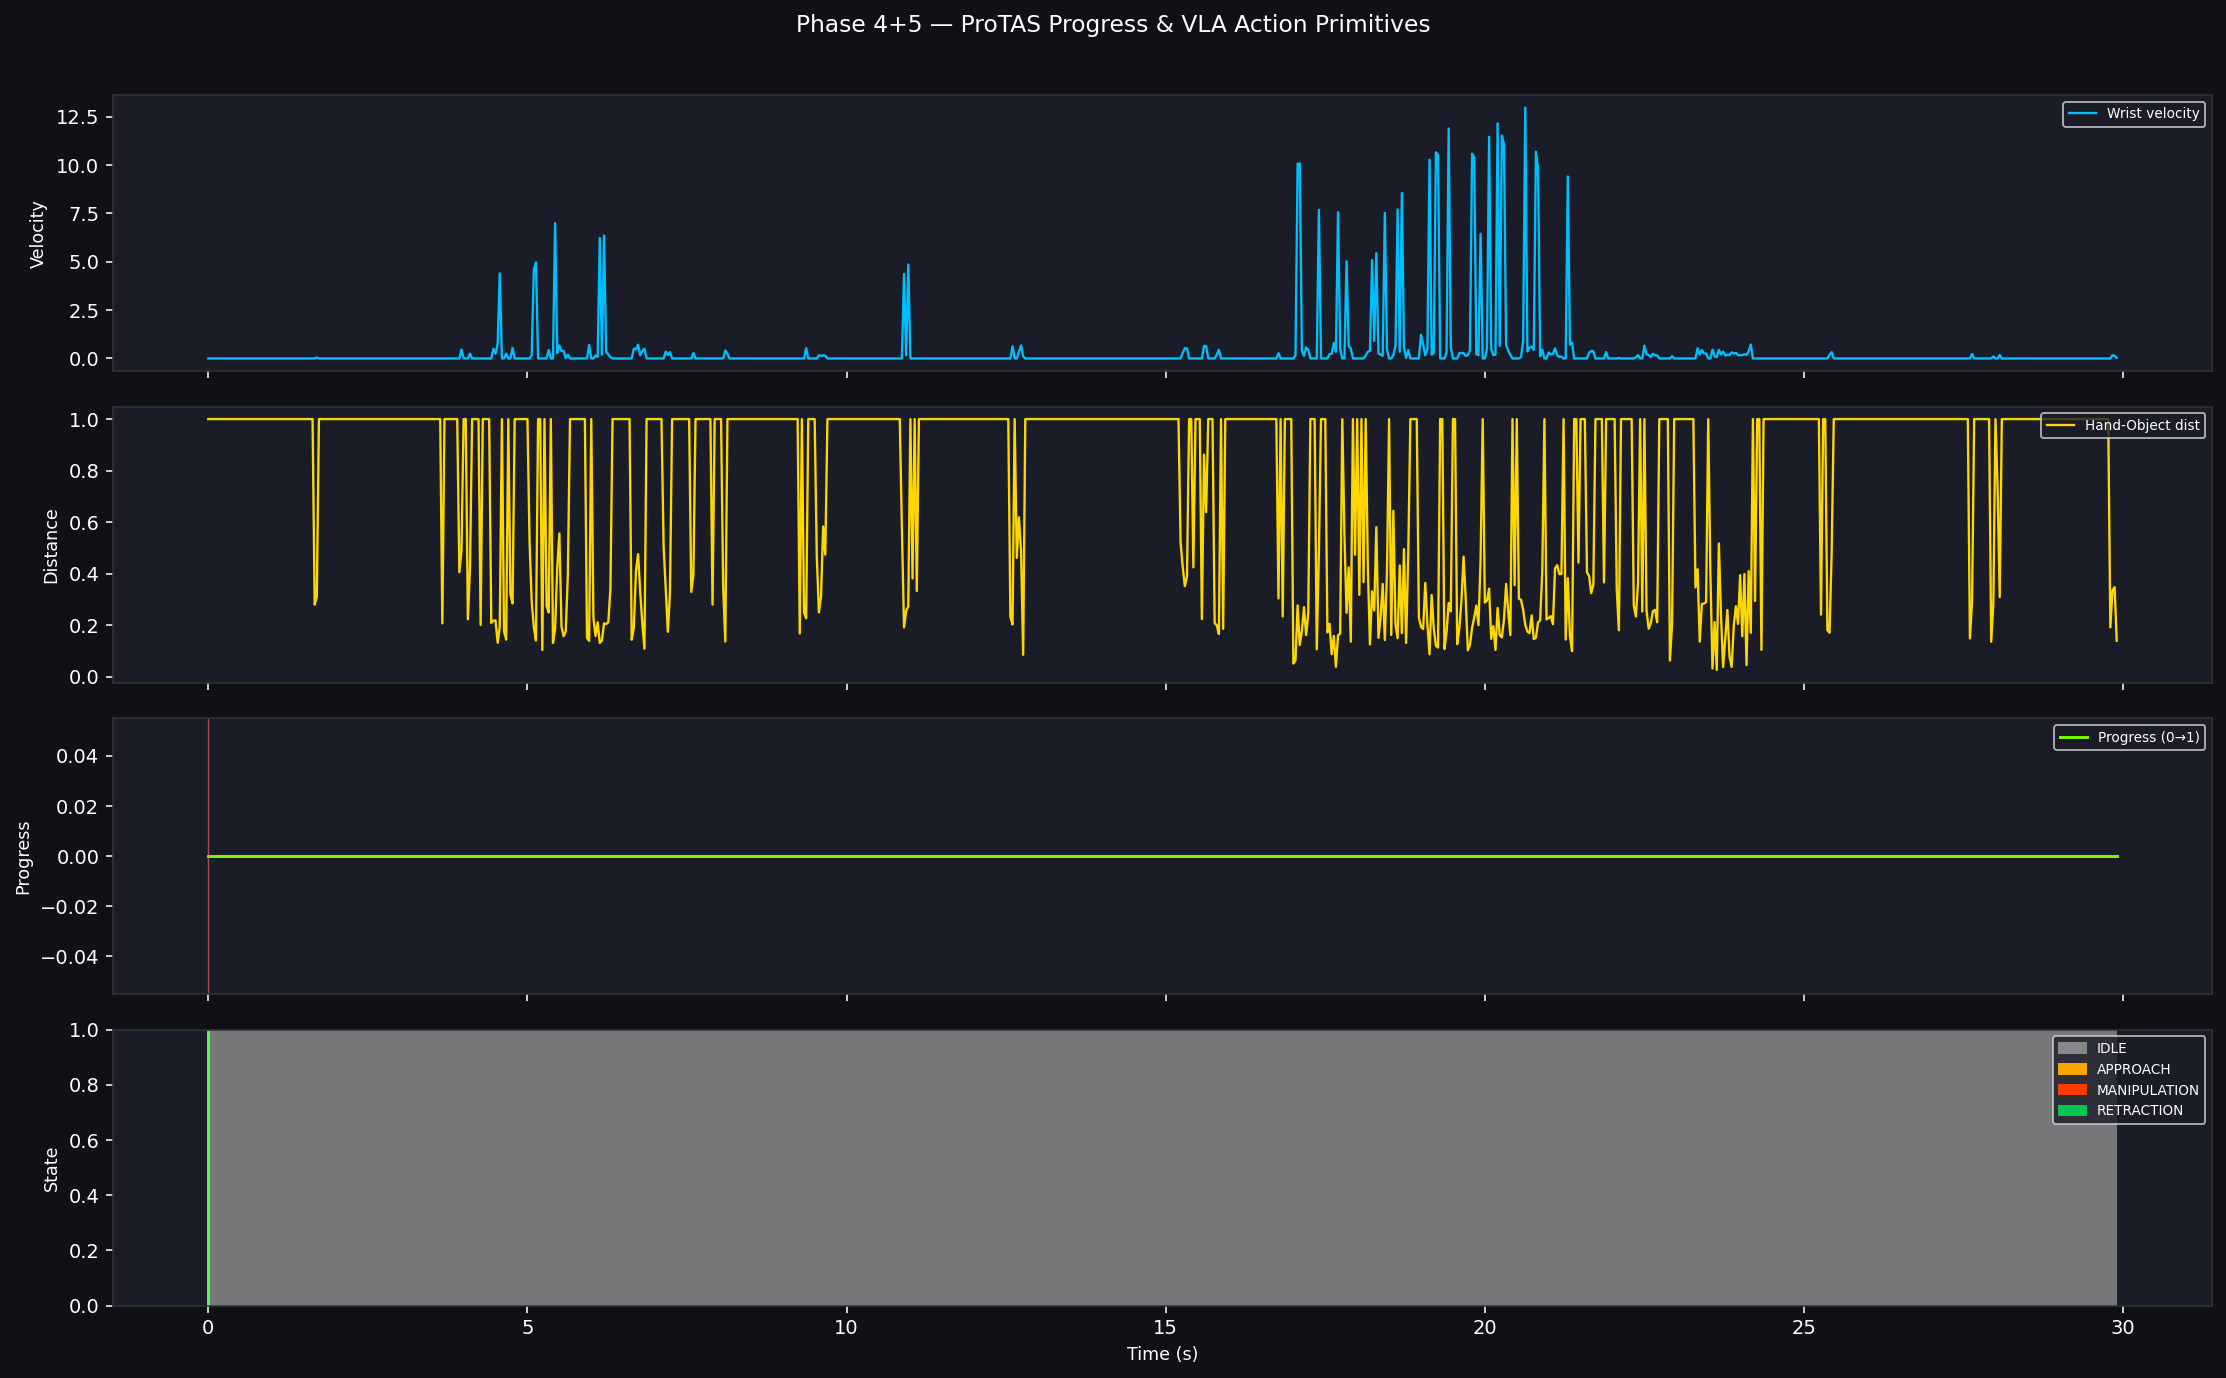


── Sample VLA Record ──
{
  "episode_index": 0,
  "clip_id": 0,
  "instruction": "Idle posture observed \u2014 awaiting next action primitive.",
  "observation": {
    "state": "IDLE",
    "progress": 0.0,
    "timestamp_s": [
      0.0,
      29.8667
    ]
  },
  "action": {
    "wrist_pose_6dof": [
      0.5,
      0.62718,
      0.5,
      -0.00033,
      0.0,
      0.0
    ],
    "relative_pose_6dof": [
      0.0,
      0.12718,
      0.0,
      -0.00033,
      0.0,
      0.0
    ],
    "mano_params": [
      -0.39373,
      -0.40032,
      0.16552,
      -0.73455,
      0.9068,
      -1.23871,
      0.16753,
      -0.41173,
      -0.20665,
      0.42663,
      -1.01152,
      -0.14811,
      -0.99483,
      -1.49945,
      -1.46979,
      1.40952
    ],
    "displacement_mag": 0.12718
  },
  "contact_events": [],
  "quality_flag": "OK",
  "coordinate_space": "unit_cube_normalized",
  "embodiment": "Human-to-Humanoid-Unified",
  "version": "2.0"
}


In [ ]:
!pip install opencv-python-headless numpy matplotlib tqdm -q

# ── Option A: pipe from real Phase 3 output ──
!python phase45_protas_vla.py --data-dir phase3_output

# ── Option B: fully synthetic, no Phase 3 needed ──
# !python phase45_protas_vla.py --synthetic

import glob, json
from IPython.display import Image, display

print("\n── Phase 4+5 Metrics ──")
meta = json.load(open('phase45_output/phase45_meta.json'))
for k, v in meta.items():
    print(f"  {k:<42} {v}")

display(Image('phase45_output/phase45_timeline_plot.png', width=900))

# Preview one VLA record
records = [json.loads(l) for l in open('phase45_output/phase45_vla.jsonl')]
print("\n── Sample VLA Record ──")
print(json.dumps(records[0], indent=2))


══════════════════════════════════════════════════════════════════════
  PHASE 6 — EgoHumanoid Quality Validation & Export Engine
══════════════════════════════════════════════════════════════════════
[INFO] Generating synthetic batch (8 clean + 2 corrupt)…
Exporting:   0% 0/10 [00:00<?, ?ep/s]  [AUDIT FAIL] corrupt_ep_101: CORRUPTED — TELEPORT×1_MAXJUMP=220.4_MAXACC=217.4
  [AUDIT FAIL] corrupt_ep_100: CORRUPTED — TELEPORT×1_MAXJUMP=260.3_MAXACC=256.3
Exporting: 100% 10/10 [00:00<00:00, 647.55ep/s]

──────────────────────────────────────────────────────────────────────
  PHASE 6 METRICS
──────────────────────────────────────────────────────────────────────
  episodes_total                                 10
  episodes_passed_physics_audit                  8
  episodes_failed_physics_audit                  2
  episode_pass_rate_%                            80.0
  frames_total                                   818
  teleport_flags_total                           2
  teleport_flag_rate_

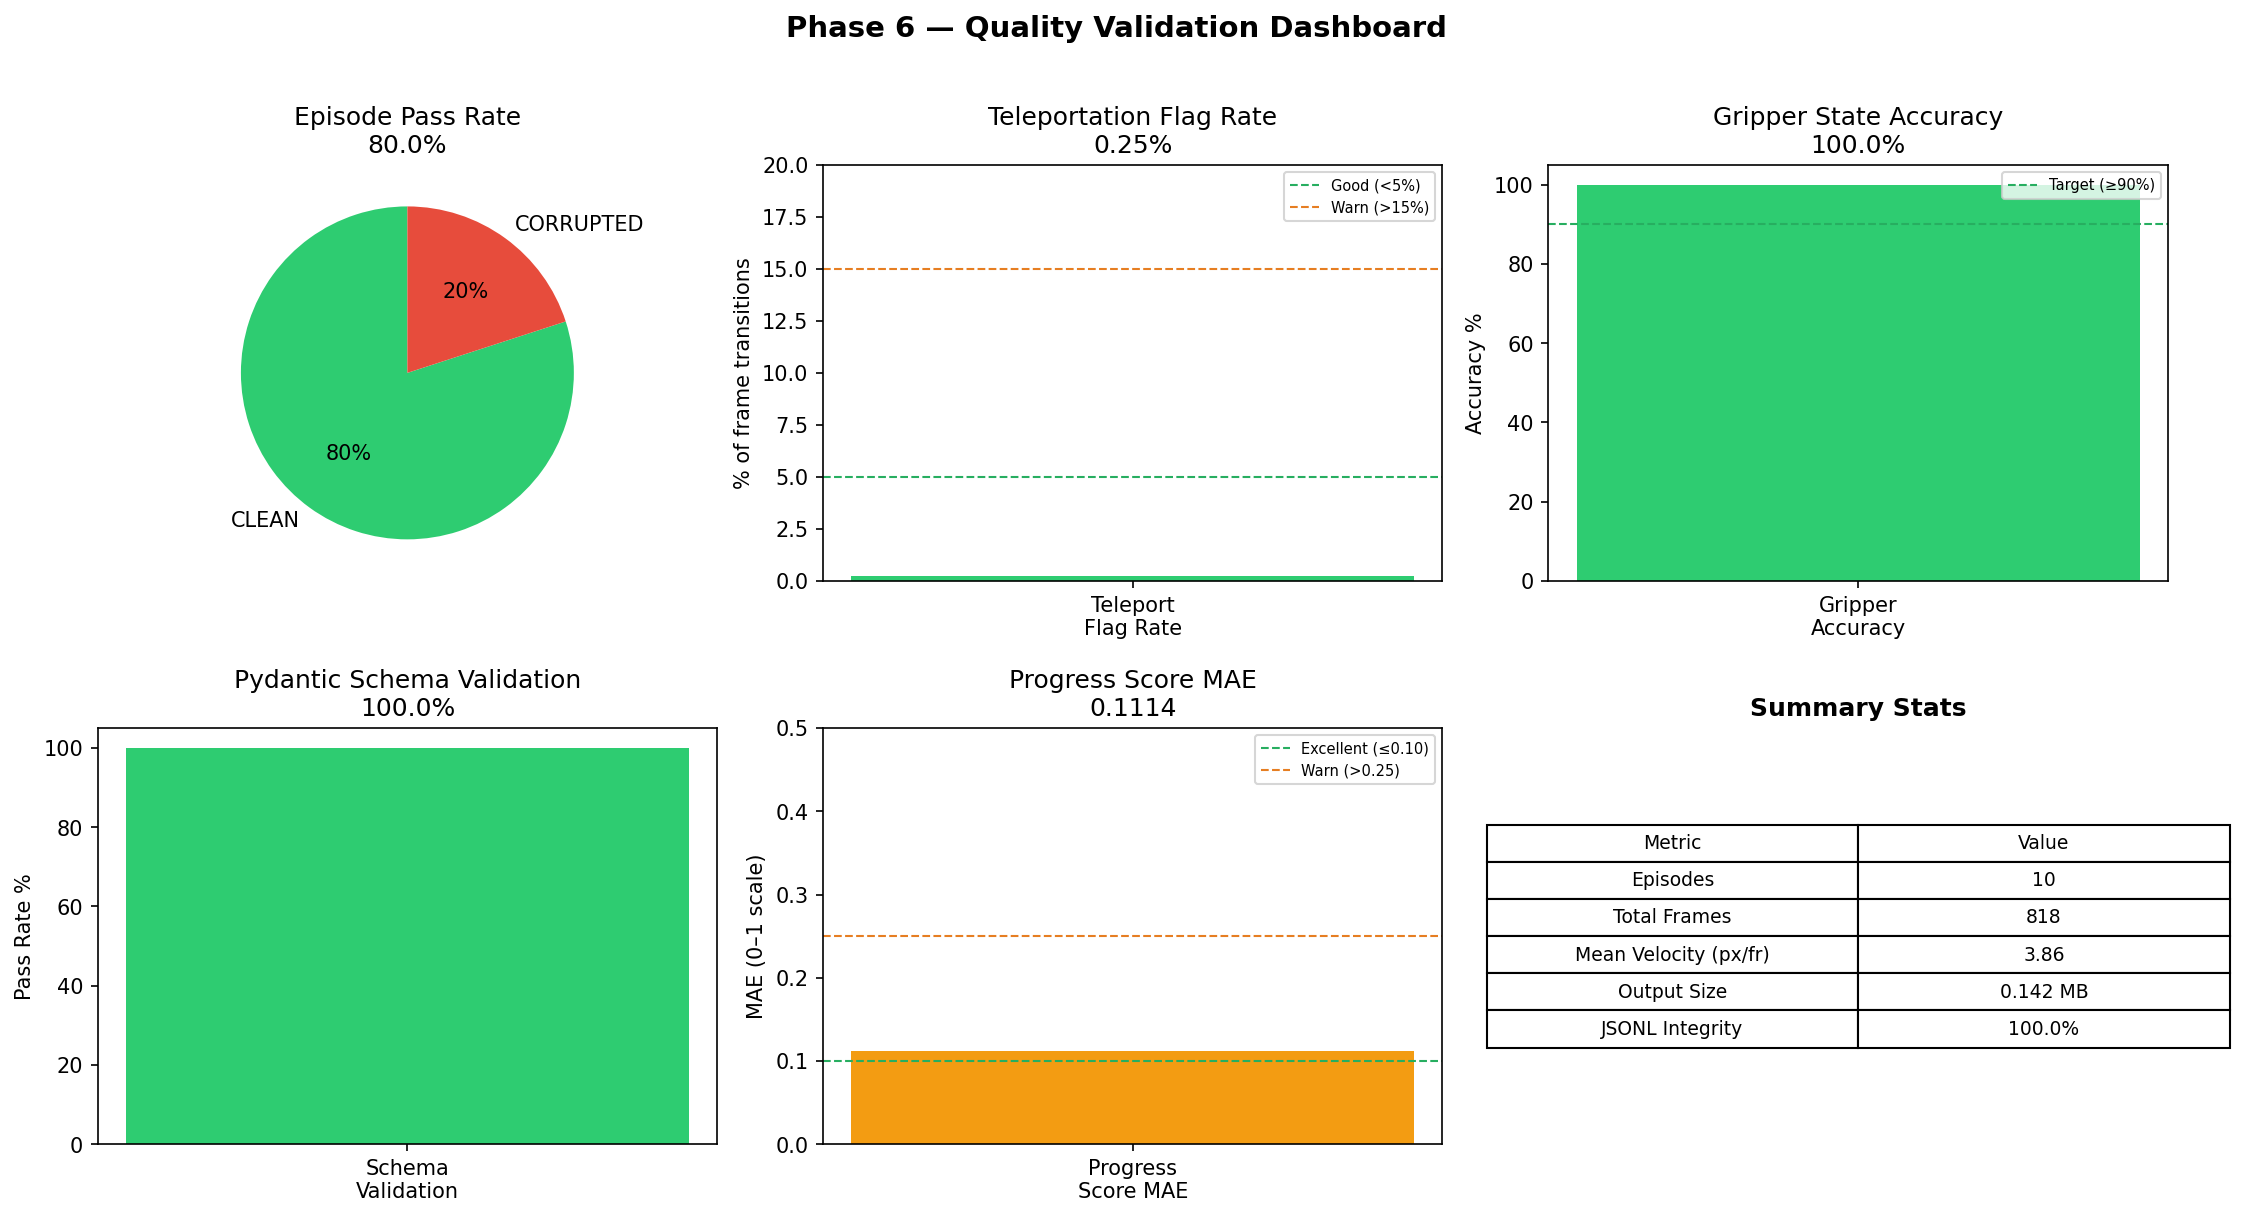


── Sample VLA Record ──
{
  "video_id": "clean_ep_006",
  "language_instruction": "Tighten the bolt on the assembly jig using the spanner.",
  "total_frames": 113,
  "metadata": {
    "audit_status": "CLEAN",
    "event_count": 2,
    "max_velocity_jump_px": 10.78,
    "mean_velocity_px_per_frame": 3.438,
    "gripper_accuracy": 1.0,
    "progress_mae": 0.1119,
    "source_pipeline": "EgoHumanoid-Phase6"
  }
}


In [ ]:
!pip install pydantic numpy matplotlib tqdm -q

# ── Option A: pipe from real Phase 4+5 output ──
# !python phase6_export_validator.py --data-dir phase45_output

# ── Option B: fully synthetic, no Phase 3/4/5 needed ──
!python phase6_export_validator.py --synthetic

import json
from IPython.display import Image, display

print("\n── Phase 6 Metrics ──")
meta = json.load(open('phase6_output/phase6_meta.json'))
for k, v in meta.items():
    print(f"  {k:<46} {v}")

display(Image('phase6_output/phase6_dashboard.png', width=950))

# Preview first CLEAN VLA record
records = [json.loads(l) for l in open('phase6_output/final_robot_dataset.jsonl')]
print("\n── Sample VLA Record ──")
import json
clean = next(r for r in records if r['metadata']['audit_status'] == 'CLEAN')
print(json.dumps({k: clean[k] for k in ['video_id','language_instruction','total_frames','metadata']}, indent=2))

In [ ]:
!pip install opencv-python-headless numpy matplotlib tqdm scipy -q
!python phase7_director_cut.py

import os
from IPython.display import HTML
from base64 import b64encode

video = 'phase7_output/PHASE7_MASTER_DASHBOARD.mp4'
if os.path.exists(video):
    !ffmpeg -y -i {video} -vcodec libx264 -crf 23 /tmp/p7.mp4 -loglevel quiet
    b64 = b64encode(open('/tmp/p7.mp4','rb').read()).decode()
    display(HTML(f'<video width="960" controls autoplay><source src="data:video/mp4;base64,{b64}" type="video/mp4"></video>'))
else:
    print("Video not found — check logs above")

  PHASE 7 — Director Cut Dashboard Video
[Load] Timeline: phase3_output/phase3_timeline.jsonl
[Load] Events: 2 contact/separation events
[Load] Velocities: 898 values
[Load] Instruction: Tighten the bolt on the assembly jig using the spanner.
[Load] Phase 1 frames: 898
[Info] Total frames to render: 898
[Info] Gripper CLOSED frames:  0
[Render] Writing → phase7_output/PHASE7_MASTER_DASHBOARD.mp4
Phase 7:  65%|██████████████████████▏           | 586/898 [01:24<00:41,  7.51fr/s]